# Student Performance Prediction — Exploratory Data Analysis

This notebook explores the UCI Student Performance dataset and prepares the data for machine learning. The analysis focuses on understanding the dataset structure, checking data quality, examining the target variable (`G3`), and identifying patterns that may influence student academic performance.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Load the Dataset

The dataset is stored locally in the `data/raw` directory. It uses semicolons (`;`) as the delimiter, so the separator must be specified when loading the CSV file with pandas.

In [24]:
DATA_PATH = "../data/raw/student-mat.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 395
Columns: 33


## Preview the Dataset

The first few rows are displayed to understand the available features and verify that the dataset was loaded correctly.

In [25]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## Dataset Structure

The dataset contains both numerical and categorical variables. We inspect the data types, number of non-null observations, and general structure before performing preprocessing.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## Numerical Summary Statistics

Summary statistics help us understand the distribution, range, mean, and variability of numerical features such as age, study time, absences, previous grades, and final grade.

In [27]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Categorical Feature Summary

Categorical variables such as school, sex, address type, family support, internet access, and extracurricular activities are summarized to understand their possible values and frequency distributions.

In [28]:
df.describe(include="object").T

/var/folders/wj/c95yg5kd1xs1fp0kl5bk171w0000gn/T/ipykernel_8175/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
school,395,2,GP,349
sex,395,2,F,208
address,395,2,U,307
famsize,395,2,GT3,281
Pstatus,395,2,T,354
Mjob,395,5,other,141
Fjob,395,5,other,217
reason,395,4,course,145
guardian,395,3,mother,273
schoolsup,395,2,no,344


## Missing Value Check

Before building machine-learning models, we check whether any features contain missing values. Missing data may require imputation or removal during preprocessing.

In [29]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


Series([], dtype: int64)

## Duplicate Row Check

Duplicate observations can bias model training and evaluation. We check whether the dataset contains any completely duplicated rows.

In [30]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Target Variable — Final Grade (`G3`)

The primary target for this project is `G3`, which represents the student's final course grade on a scale from 0 to 20. We first examine its descriptive statistics and frequency distribution.

In [31]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

### Final Grade Frequency

The frequency of each final grade helps reveal whether the target distribution is balanced or concentrated around certain scores.

In [32]:
df["G3"].value_counts().sort_index()

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

### Final Grade Distribution

The histogram below visualizes the distribution of final grades across students. This helps identify the most common grade ranges and whether the target contains any unusual concentrations or extreme values.

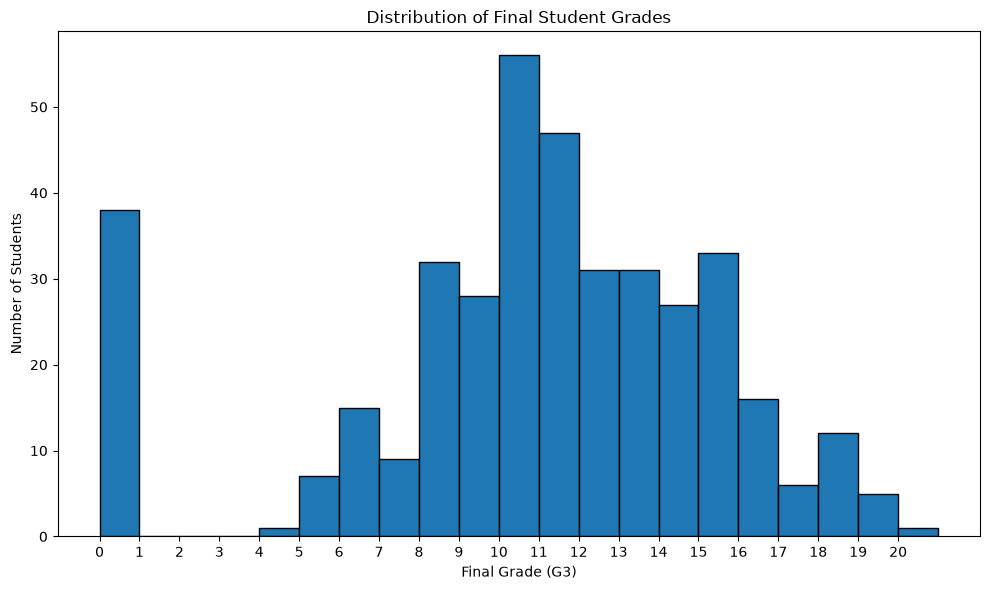

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(df["G3"], bins=range(0, 22), edgecolor="black")

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.xticks(range(0, 21))
plt.tight_layout()
plt.show()

## Feature Overview

The dataset contains a mixture of numerical and categorical features. Separating these feature types helps determine which exploratory techniques and preprocessing methods will be appropriate before model training.

In [34]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 16
Number of categorical features: 17

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/var/folders/wj/c95yg5kd1xs1fp0kl5bk171w0000gn/T/ipykernel_8175/2845231542.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object"]).columns.tolist()


## Correlation with Final Grade

Pearson correlation is used to examine the linear relationship between numerical features and the final grade (`G3`). Features with larger positive or negative correlation values may contain useful predictive information.

Correlation does not imply causation; this analysis is used only to identify relationships that may be relevant for prediction.

In [35]:
correlations = (
    df[numerical_features]
    .corr()["G3"]
    .drop("G3")
    .sort_values(ascending=False)
)

correlations

G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

### Numerical Feature Correlations

The following chart compares the correlation of each numerical feature with the final grade. This provides an initial view of which numerical variables are most strongly associated with academic performance.

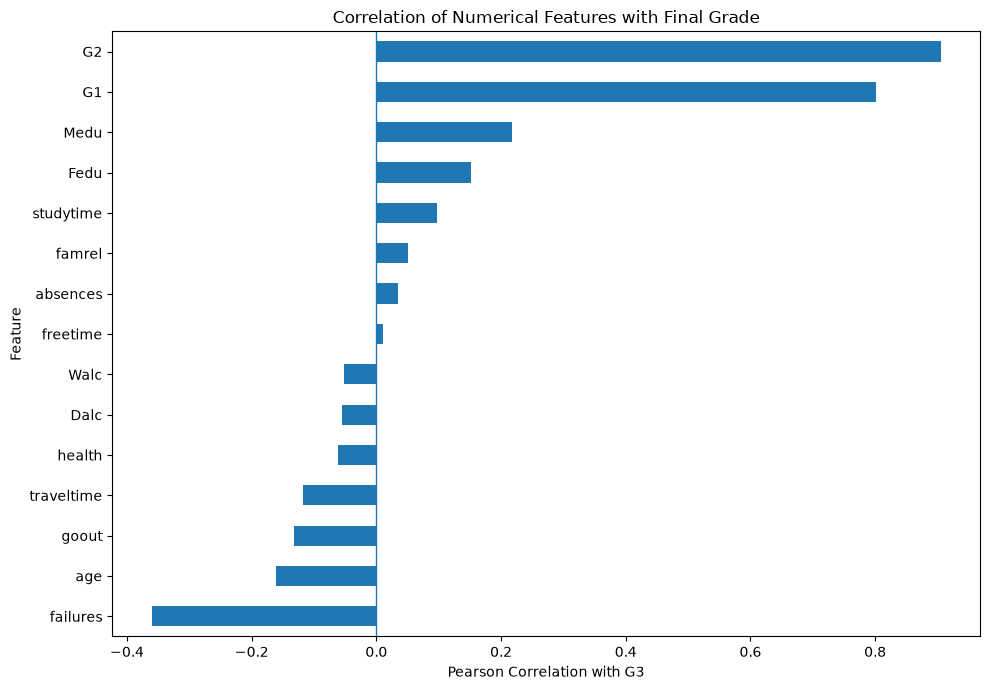

In [36]:
plt.figure(figsize=(10, 7))

correlations.sort_values().plot(kind="barh")

plt.title("Correlation of Numerical Features with Final Grade")
plt.xlabel("Pearson Correlation with G3")
plt.ylabel("Feature")

plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

## Previous Grades and Final Performance

The dataset contains three grade variables:

- `G1` — first-period grade
- `G2` — second-period grade
- `G3` — final grade

Because `G1` and `G2` represent earlier academic performance, they may be highly predictive of the final grade. Their relationship with `G3` is examined before deciding whether they should be included in the final prediction system.

In [37]:
grade_correlations = df[["G1", "G2", "G3"]].corr()

grade_correlations

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


### Second-Period Grade vs. Final Grade

A scatter plot is used to examine how strongly the second-period grade (`G2`) is associated with the final grade (`G3`).

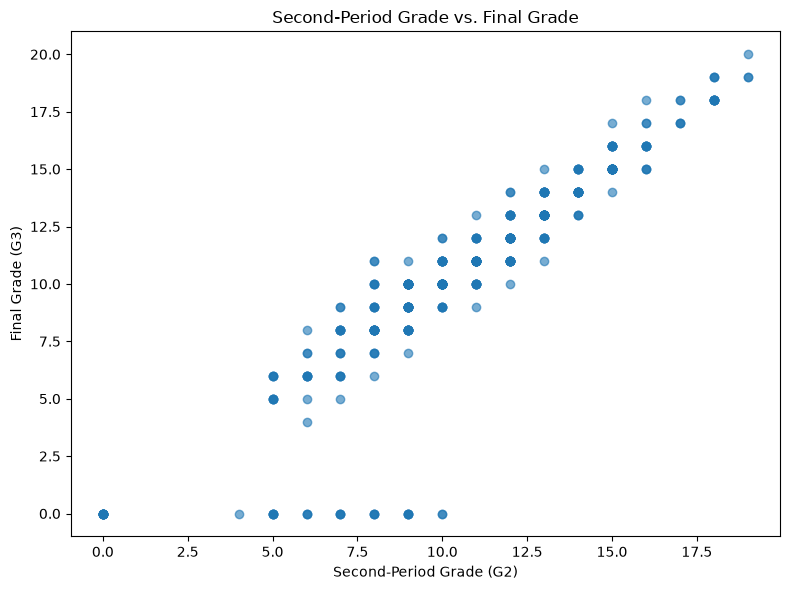

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(df["G2"], df["G3"], alpha=0.6)

plt.title("Second-Period Grade vs. Final Grade")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

## Study Time and Academic Performance

Study time is an intuitive behavioral feature that may be associated with academic performance. The average final grade is compared across the dataset's study-time categories.

In [39]:
studytime_performance = (
    df.groupby("studytime")["G3"]
    .agg(["mean", "median", "count"])
)

studytime_performance

,mean,median,count
studytime,,,
1,10.047619,10.0,105
2,10.171717,11.0,198
3,11.400000,12.0,65
4,11.259259,12.0,27


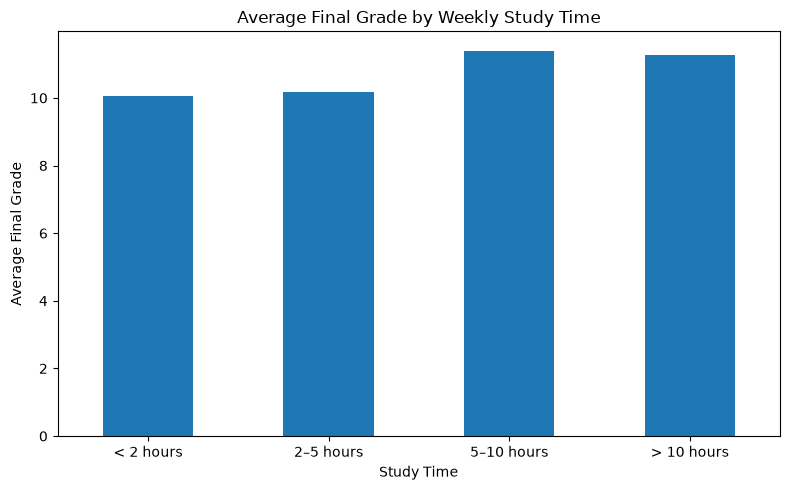

In [40]:
studytime_labels = {
    1: "< 2 hours",
    2: "2–5 hours",
    3: "5–10 hours",
    4: "> 10 hours"
}

studytime_means = (
    df.groupby("studytime")["G3"]
    .mean()
    .rename(index=studytime_labels)
)

plt.figure(figsize=(8, 5))

studytime_means.plot(kind="bar")

plt.title("Average Final Grade by Weekly Study Time")
plt.xlabel("Study Time")
plt.ylabel("Average Final Grade")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Previous Failures and Final Grade

The number of previous class failures may provide information about a student's historical academic performance. We compare final grades across different numbers of previous failures.

In [41]:
failure_performance = (
    df.groupby("failures")["G3"]
    .agg(["mean", "median", "count"])
)

failure_performance

,mean,median,count
failures,,,
0,11.253205,11.0,312
1,8.120000,9.0,50
2,6.235294,8.0,17
3,5.687500,7.0,16


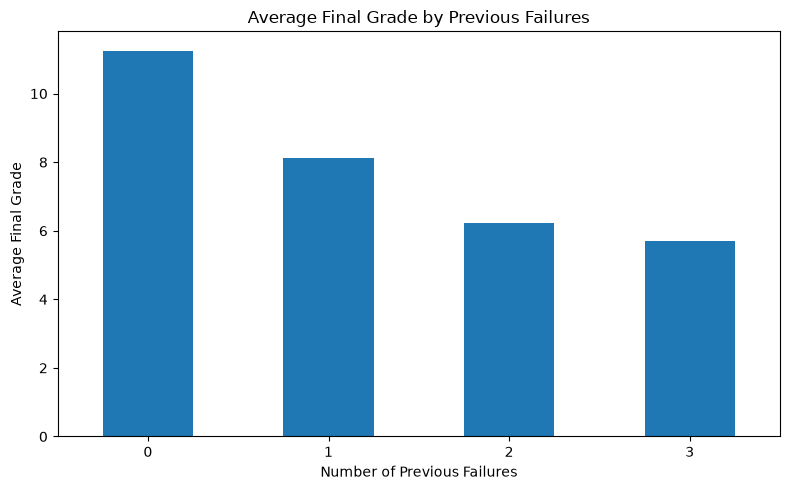

In [42]:
plt.figure(figsize=(8, 5))

df.groupby("failures")["G3"].mean().plot(kind="bar")

plt.title("Average Final Grade by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Absences and Final Grade

Student attendance may also be related to academic outcomes. A scatter plot is used to examine the relationship between the number of recorded absences and the final grade.

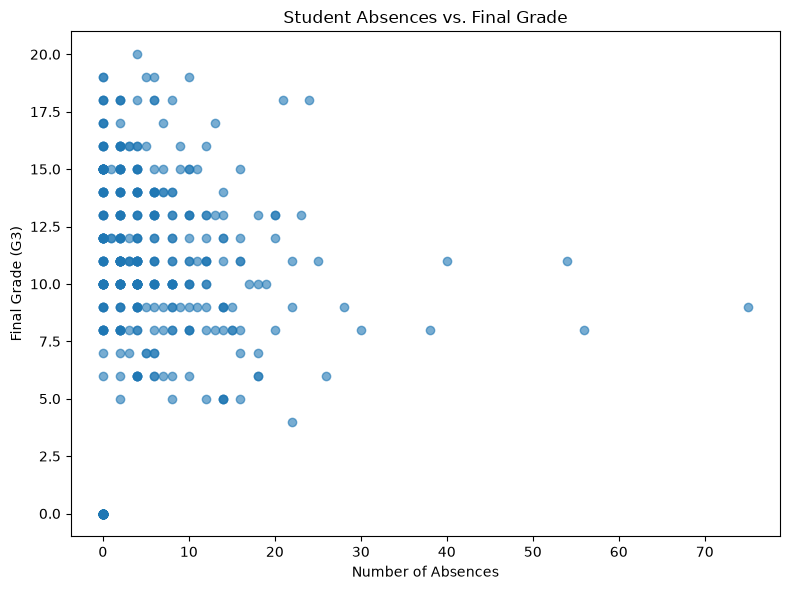

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(df["absences"], df["G3"], alpha=0.6)

plt.title("Student Absences vs. Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

## Categorical Features and Academic Performance

Several categorical variables describe student resources, educational support, and activities. Their average final grades are compared to identify potential differences between groups.

In [44]:
categorical_analysis = [
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "higher",
    "internet"
]

for feature in categorical_analysis:
    print(f"\nAverage G3 by {feature}:")
    print(df.groupby(feature)["G3"].agg(["mean", "median", "count"]))


Average G3 by schoolsup:
                mean  median  count
schoolsup                          
no         10.561047    11.0    344
yes         9.431373    10.0     51

Average G3 by famsup:
             mean  median  count
famsup                          
no      10.640523    11.0    153
yes     10.272727    11.0    242

Average G3 by paid:
           mean  median  count
paid                          
no     9.985981    11.0    214
yes   10.922652    11.0    181

Average G3 by activities:
                 mean  median  count
activities                          
no          10.340206    11.0    194
yes         10.487562    11.0    201

Average G3 by higher:
          mean  median  count
higher                       
no       6.800     8.0     20
yes     10.608    11.0    375

Average G3 by internet:
               mean  median  count
internet                          
no         9.409091    10.0     66
yes       10.617021    11.0    329
